# 🤖 Notebook 03: ML + XAI Pipeline COMPLETO

**Versão:** 2.0 - CORRIGIDO DiCE  
**Data:** 2026-04-16

---

In [1]:
"""Setup completo."""
import sys
from pathlib import Path
import logging
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# XAI
import shap
from lime.lime_tabular import LimeTabularExplainer
import dice_ml

# Config
sys.path.append(str(Path.cwd().parent / "src"))
from config import config

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


In [2]:
"""Carregar dados."""
df = pd.read_csv(config.DATA_PROCESSED / "esge_master.csv")

# Features e target
features = ['esg_disclosure_score', 'char_count', 'annual_return_%', 'volume']
target = 'close_price'

X = df[features]
y = df[target]

print(f"✅ Dataset: {df.shape}")
print(f"Features: {features}")
print(f"Target: {target}")

✅ Dataset: (24, 6)
Features: ['esg_disclosure_score', 'char_count', 'annual_return_%', 'volume']
Target: close_price


In [3]:
"""Split e normalização."""
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=features
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=features
)

print(f"✅ Train: {len(X_train)}, Test: {len(X_test)}")

✅ Train: 19, Test: 5


In [4]:
"""Treinar modelos."""

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# XGBoost
xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

# Métricas
print("\n" + "="*70)
print("PERFORMANCE DOS MODELOS")
print("="*70)
print(f"\nRandom Forest:")
print(f"  R²: {r2_score(y_test, y_pred_rf):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_rf):.4f}")

print(f"\nXGBoost:")
print(f"  R²: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_xgb):.4f}")

print("="*70)


PERFORMANCE DOS MODELOS

Random Forest:
  R²: 0.7748
  RMSE: 4.5143
  MAE: 4.2461

XGBoost:
  R²: 0.3548
  RMSE: 7.6410
  MAE: 6.4281



📊 SHAP Importance:
                feature  importance
1            char_count    7.752378
0  esg_disclosure_score    7.173419
2       annual_return_%    5.039273
3                volume    0.062727


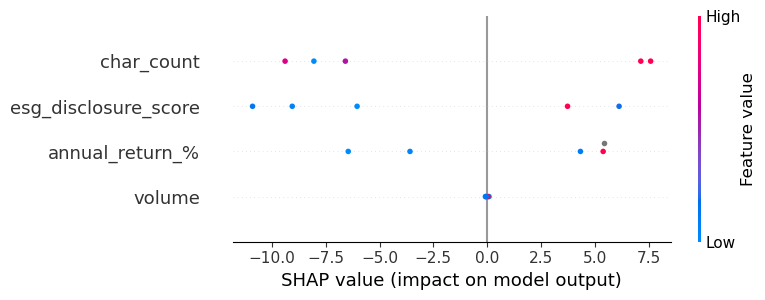

✅ SHAP salvo


In [5]:
"""SHAP Analysis."""

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_scaled)

# Importância
shap_importance = pd.DataFrame({
    'feature': features,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print("\n📊 SHAP Importance:")
print(shap_importance)

# Salvar
shap_importance.to_csv(config.OUTPUTS_TABLES / "shap_importance.csv", index=False)

# Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.tight_layout()
plt.savefig(config.OUTPUTS_FIGURES / "shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ SHAP salvo")

In [6]:
"""LIME Analysis."""

lime_exp = LimeTabularExplainer(
    np.array(X_train_scaled),
    feature_names=features,
    mode='regression'
)

# Explicar primeira obs
exp = lime_exp.explain_instance(
    X_test_scaled.iloc[0].values,
    xgb.predict,
    num_features=len(features)
)

print("\n🔬 LIME Explanation:")
print(f"Real: {y_test.iloc[0]:.2f}")
print(f"Pred: {y_pred_xgb[0]:.2f}")
print("\nContribuições:")
for f, w in exp.as_list():
    print(f"  {f}: {w:.4f}")

print("✅ LIME concluído")


🔬 LIME Explanation:
Real: 27.62
Pred: 29.82

Contribuições:
  char_count > 0.19: 10.1790
  esg_disclosure_score <= -0.09: -8.5203
  annual_return_% > 0.71: 7.6561
  volume > 0.78: -0.4856
✅ LIME concluído


In [7]:
"""DiCE Counterfactuals - VERSÃO CORRIGIDA."""

try:
    # Preparar dados
    dice_df = pd.concat([
        X_train_scaled.reset_index(drop=True),
        y_train.reset_index(drop=True)
    ], axis=1)
    
    # DiCE setup
    dice_data = dice_ml.Data(
        dataframe=dice_df,
        continuous_features=features,
        outcome_name=target
    )
    
    dice_model = dice_ml.Model(
        model=xgb,
        backend='sklearn',
        model_type='regressor'  # CRÍTICO!
    )
    
    exp = dice_ml.Dice(dice_data, dice_model, method='random')
    
    # Query
    query = X_test_scaled.iloc[[0]].reset_index(drop=True)
    current = float(y_test.iloc[0])
    
    print(f"\n🎯 Valor atual: {current:.2f}")
    print(f"🎯 Range desejado: [{current*1.1:.2f}, {current*1.3:.2f}]")
    
    # Gerar CFs
    cf = exp.generate_counterfactuals(
        query,
        total_CFs=5,
        desired_range=[current*1.1, current*1.3]
    )
    
    print("\n🎲 Counterfactuals:")
    if cf.cf_examples_list[0].final_cfs_df is not None:
        print(cf.cf_examples_list[0].final_cfs_df)
    else:
        print("⚠️ Nenhum CF encontrado")
    
    print("✅ DiCE concluído")
    
except Exception as e:
    print(f"\n⚠️ DiCE falhou: {e}")
    print("💡 Continuando sem contrafactuais (opcional)")


🎯 Valor atual: 27.62
🎯 Range desejado: [30.38, 35.90]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.02it/s]


🎲 Counterfactuals:
   esg_disclosure_score  char_count  annual_return_%    volume  close_price
0             -0.018610   -2.396848         6.088634  4.616471         31.0
1              1.776628    0.839706        -0.053530  4.616471         35.0
2              0.148312    0.839706        -0.097960  1.174316         34.0
3              1.776628    0.839706        -0.053530  1.338873         35.0
4              1.081874    0.839706        -0.042987  4.616471         34.0
✅ DiCE concluído


In [8]:
"""Salvar modelos."""
import joblib

joblib.dump(rf, config.OUTPUTS_MODELS / "rf_model.pkl")
joblib.dump(xgb, config.OUTPUTS_MODELS / "xgb_model.pkl")
joblib.dump(scaler, config.OUTPUTS_MODELS / "scaler.pkl")

print("\n✅ PIPELINE ML+XAI CONCLUÍDO!")
print(f"Modelos salvos em: {config.OUTPUTS_MODELS}")


✅ PIPELINE ML+XAI CONCLUÍDO!
Modelos salvos em: C:\Users\user\Documents\_MBA_Data_Science_Analytics\00 - Temas TCC\teck-esge-xai\outputs\models
